# Demographic Segmentation – Clustering
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

This notebook focuses on customer segmentation from a demographic perspective. Using geographic and socioeconomic variables, we prepare the data for clustering by inspecting distributions, handling potential outliers, encoding selected demographic attributes, and scaling numerical features. The goal is to create a clean and consistent dataset that can be used in later stages to identify meaningful customer segments based on demographic characteristics.

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#1st-bullet)<br>

[**Data Preposessing**](#2nd-bullet)<br>

    
</div>

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, r2_score
from kmodes.kprototypes import KPrototypes
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import ListedColormap

In [47]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

In [48]:
df_demo = df_AIAI_Master[[
    'Latitude',
    'Longitude',
    'Income',
    'Gender',
    'Marital Status',
    'Education'  
]].copy()

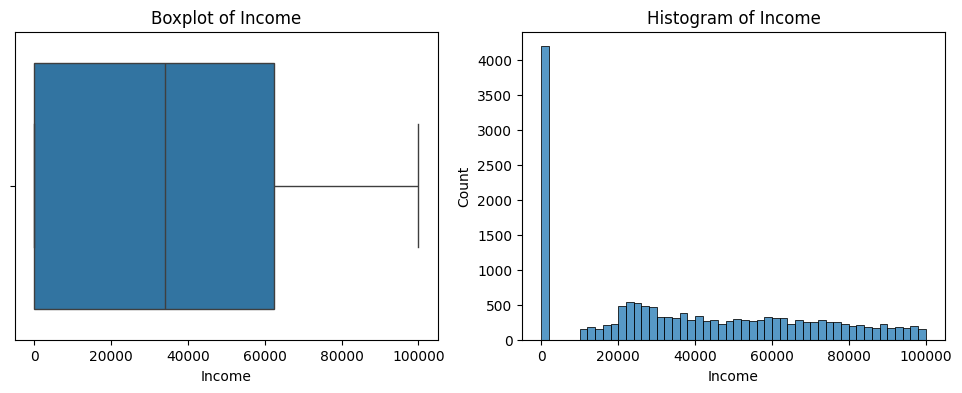

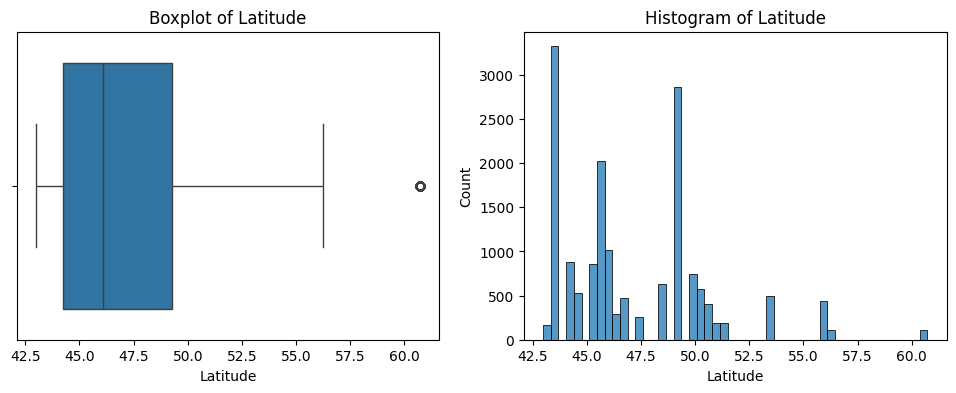

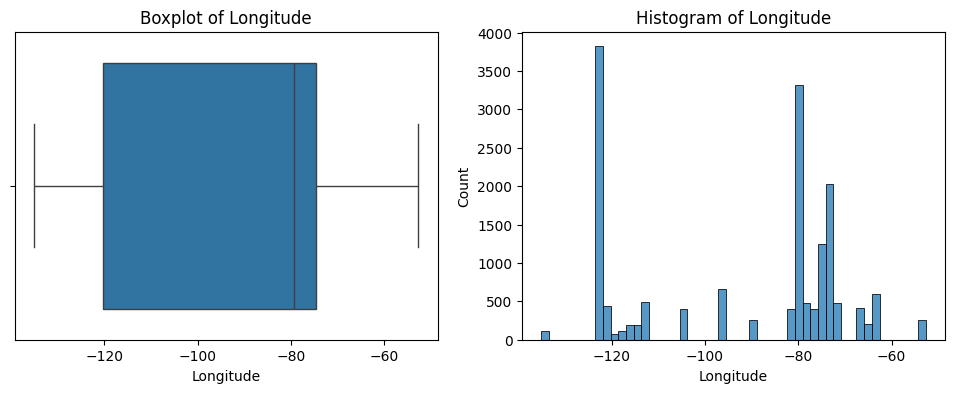

In [49]:
num_vars = ['Income', 'Latitude', 'Longitude']

for var in num_vars:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=df_demo[var], ax=ax[0])
    sns.histplot(df_demo[var], bins=50, ax=ax[1])
    ax[0].set_title(f'Boxplot of {var}')
    ax[1].set_title(f'Histogram of {var}')
    plt.show()

In [50]:
df_demo_ceiled = df_demo.copy()

for var in ['Income', 'Latitude', 'Longitude']:
    Q1 = df_demo_ceiled[var].quantile(0.25)
    Q3 = df_demo_ceiled[var].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR

    df_demo_ceiled[var] = np.where(
        df_demo_ceiled[var] > upper_bound,
        upper_bound,
        df_demo_ceiled[var]
    )

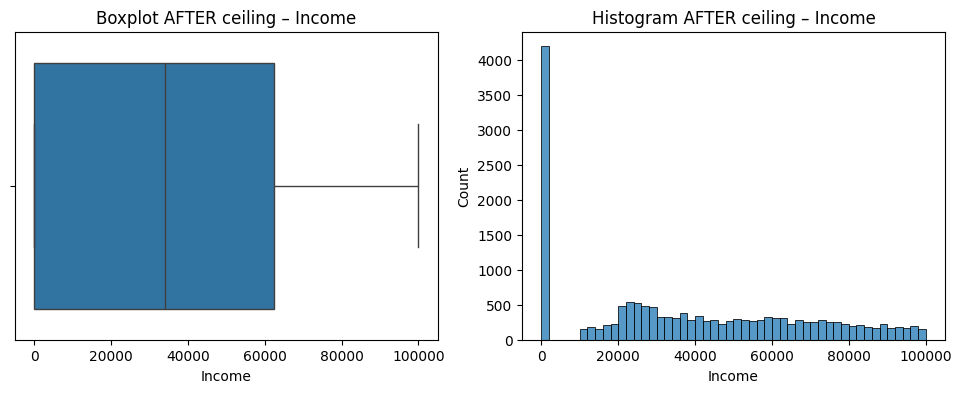

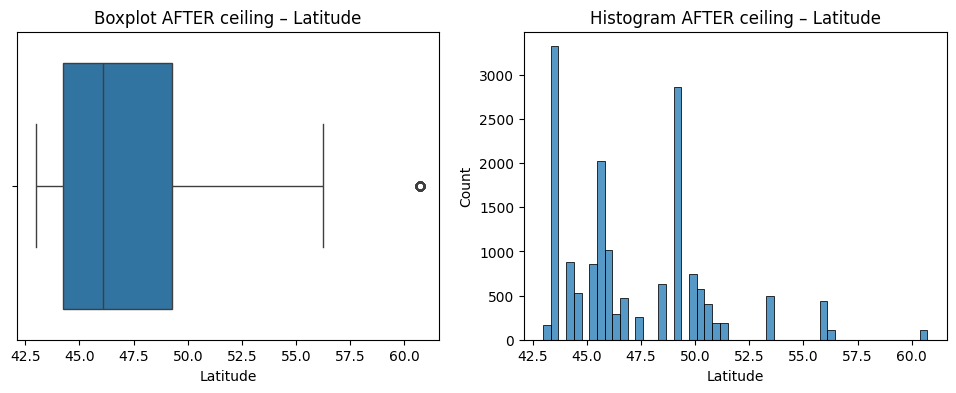

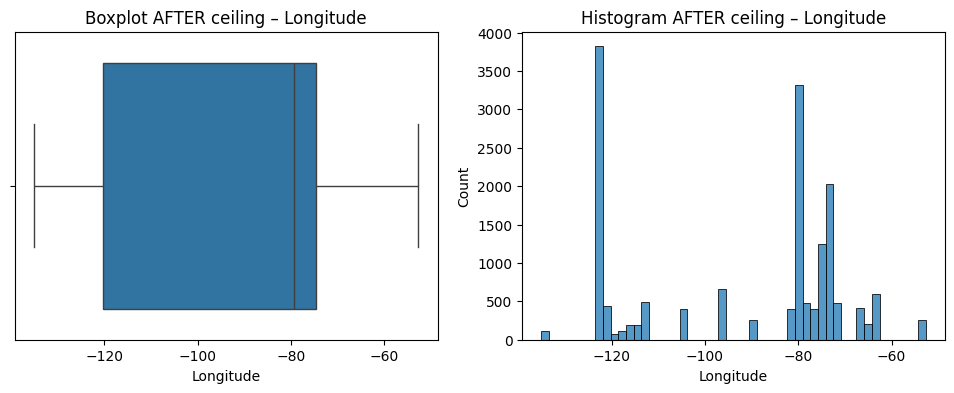

In [51]:
for var in ['Income', 'Latitude', 'Longitude']:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=df_demo_ceiled[var], ax=ax[0])
    sns.histplot(df_demo_ceiled[var], bins=50, ax=ax[1])
    ax[0].set_title(f'Boxplot AFTER ceiling – {var}')
    ax[1].set_title(f'Histogram AFTER ceiling – {var}')
    plt.show()

After comparing the boxplots and histograms before and after applying the 3×IQR ceiling, no meaningful changes were observed. This shows that income and geographic variables do not contain extreme outliers and are already well behaved.

In [52]:
X_demo = df_demo_ceiled[['Latitude', 'Longitude', 'Income']]

scaler = MinMaxScaler()
X_demo_scaled = scaler.fit_transform(X_demo)

K-means clustering will be performed using only continuous demographic variables (Income, Latitude, Longitude). Gender and marital status will be incorporated later during cluster profiling to characterize the segments.

<a class="anchor" id="3rd-bullet"></a>
## Demographic Clustering – K-Means

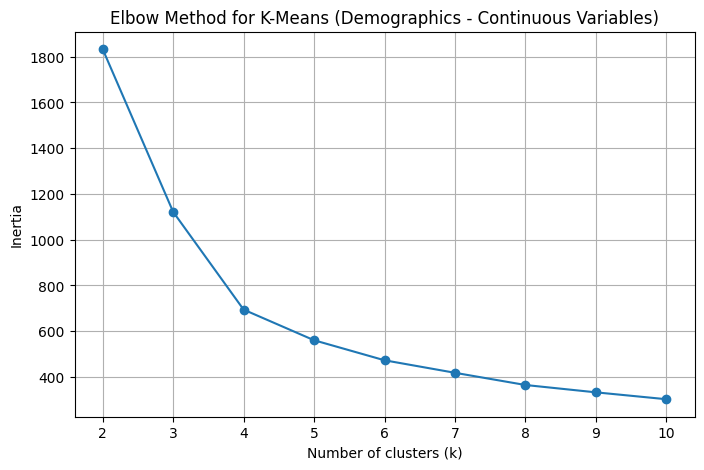

In [53]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_demo_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means (Demographics - Continuous Variables)')
plt.grid(True)
plt.show()

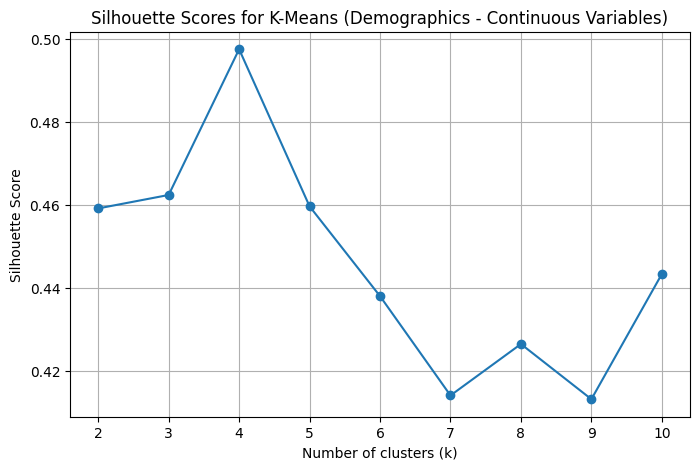

k=2: 0.4592
k=3: 0.4624
k=4: 0.4975
k=5: 0.4597
k=6: 0.4381
k=7: 0.4142
k=8: 0.4265
k=9: 0.4133
k=10: 0.4434


In [54]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_demo_scaled)
    score = silhouette_score(X_demo_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means (Demographics - Continuous Variables)')
plt.grid(True)
plt.show()

# Print scores for clarity
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

Both the elbow method and silhouette analysis indicate that k=4 provides the optimal clustering solution. The elbow plot shows diminishing returns after k=4, and the silhouette score reaches its maximum at this value (0.4975), indicating the best balance between cluster cohesion and separation.

### Final K-Means Model (k = 4)

In [55]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
demo_clusters = kmeans_final.fit_predict(X_demo_scaled)

df_demo_ceiled['Cluster'] = demo_clusters

In [56]:
cluster_counts = df_demo_ceiled['Cluster'].value_counts().sort_index()
cluster_counts

Cluster
0    5793
1    2762
2    3735
3    4282
Name: count, dtype: int64

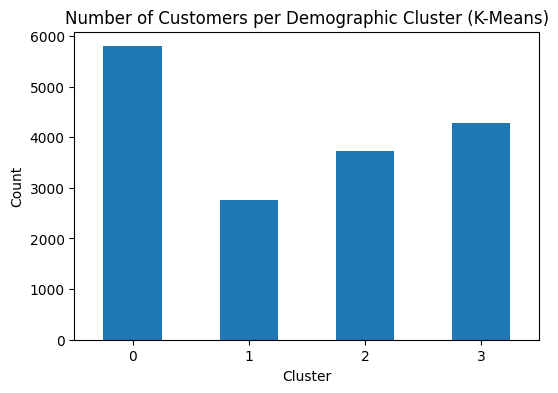

In [57]:
cluster_counts.plot(kind='bar', figsize=(6,4))
plt.title('Number of Customers per Demographic Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

The four clusters show reasonable size distribution, with no degenerate or overly small clusters, indicating a stable segmentation solution.

In [58]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=['Latitude', 'Longitude', 'Income']
)
centroids_df['Cluster'] = centroids_df.index
centroids_df

,Latitude,Longitude,Income,Cluster
0,44.955855,-75.116649,15282.278536,0
1,50.611173,-118.012702,68330.728525,1
2,50.638023,-117.906328,15108.109684,2
3,44.938646,-74.845818,68149.278245,3


In [59]:
# Cluster profiling with all demographic variables
cluster_profile = df_demo_ceiled.groupby('Cluster')[['Income', 'Latitude', 'Longitude']].mean()
print("\nCluster Profiles (Mean Values):")
print(cluster_profile)

# Add gender, marital and education status distributions
print("\n" + "="*60)
print("Gender Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster'], df_demo_ceiled['Gender'], normalize='index') * 100)

print("\n" + "="*60)
print("Marital Status Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster'], df_demo_ceiled['Marital Status'], normalize='index') * 100)

print("\n" + "="*60)
print("Education Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster'], df_demo_ceiled['Education'], normalize='index') * 100)


Cluster Profiles (Mean Values):
               Income   Latitude   Longitude
Cluster                                     
0        15291.401174  44.955724  -75.117118
1        68301.873642  50.611912 -118.011487
2        15086.698527  50.637498 -117.907141
3        68161.629145  44.938814  -74.845057

Gender Distribution by Cluster:
Gender      female       male
Cluster                      
0        49.594338  50.405662
1        51.701665  48.298335
2        50.923695  49.076305
3        49.789818  50.210182

Marital Status Distribution by Cluster:
Marital Status   Divorced    Married     Single
Cluster                                        
0               14.690143  50.819955  34.489902
1               15.242578  68.139030  16.618392
2               14.591700  51.030790  34.377510
3               15.623540  68.028958  16.347501

Education Distribution by Cluster:
Education    Bachelor    College    Doctor  High School or Below    Master
Cluster                                     

The four demographic clusters reveal distinct segments based primarily on **income and geographic location**:

- **Clusters 0 and 2**: Low-income segments (about $15,000 annual income) located in eastern and western regions respectively
- **Clusters 1 and 3**: High-income segments (about $68,000 annual income) also distributed across eastern and western regions

Gender distribution is relatively balanced across all clusters (49-52% female). However, marital status shows variation: high-income clusters have notably higher marriage rates (~68%) compared to low-income clusters (~51%), suggesting household composition correlates with income levels. Geographic location creates regional variants within income tiers, indicating both income and geography drive the segmentation.

In [76]:
# Assign descriptive names to K-Means clusters
cluster_names = {
    0: 'Low-Income East',
    1: 'High-Income West',
    2: 'Low-Income West',
    3: 'High-Income East'
}

df_demo_ceiled['Cluster_Name'] = df_demo_ceiled['Cluster'].map(cluster_names)

print("Cluster Names and Sizes:")
print(df_demo_ceiled['Cluster_Name'].value_counts())

Cluster Names and Sizes:
Cluster_Name
Low-Income East     5793
High-Income East    4282
Low-Income West     3735
High-Income West    2762
Name: count, dtype: int64


In [60]:
cluster_cmap = ListedColormap(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

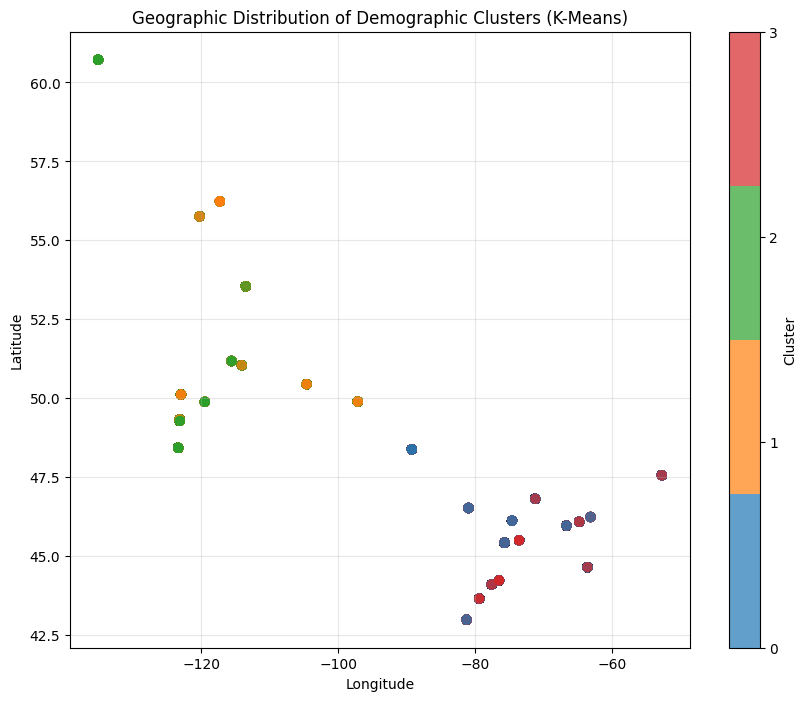

In [61]:
# Geographic visualization of clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_demo_ceiled['Longitude'],
    df_demo_ceiled['Latitude'],
    c=df_demo_ceiled['Cluster'],
    cmap=cluster_cmap,
    alpha=0.7,
    s=40
)

cbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
cbar.set_label('Cluster')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Demographic Clusters (K-Means)')
plt.grid(True, alpha=0.3)
plt.show()

The map displays customers colored by their demographic cluster assignment:

- **Cluster 0** (blue): Low income, eastern region (around Long -75°, Lat 45°)
- **Cluster 1** (orange): High income, western region (around Long -118°, Lat 51°)  
- **Cluster 2** (green): Low income, western region (around Long -118°, Lat 50°)
- **Cluster 3** (red): High income, eastern region (around Long -75°, Lat 45°)

The geographic visualization shows two distinct regional clusters. A western group (Clusters 1 and 2, around longitude -120°) and an eastern group (Clusters 0 and 3, around longitude -70°). Within each geographic region, customers are further segmented by income level, with high-income and low-income clusters occupying the same geographic areas.

c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Conside

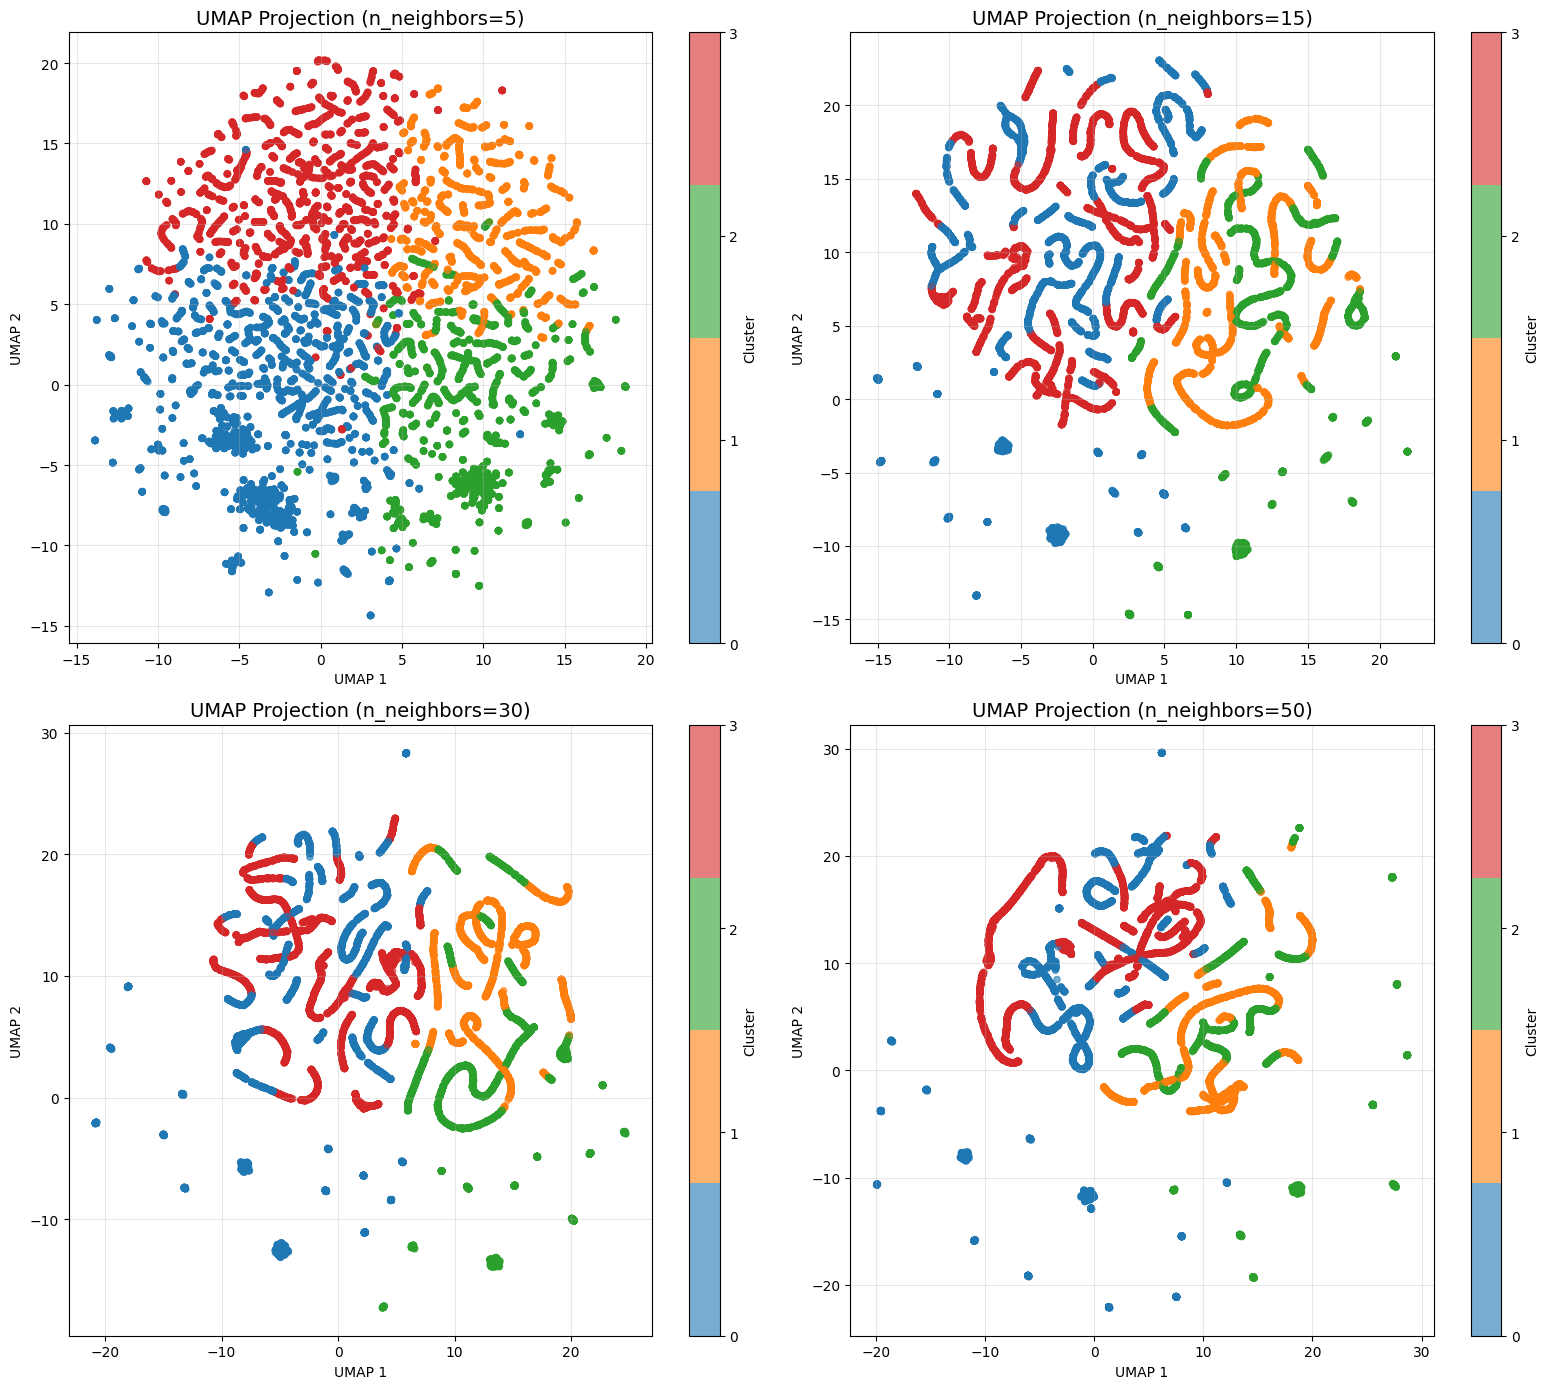

In [63]:
# Test different n_neighbors values
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
n_neighbors_values = [5, 15, 30, 50]

for idx, n_neighbors in enumerate(n_neighbors_values):
    ax = axes[idx // 2, idx % 2]
    
    # Create UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(X_demo_scaled)
    
    # Plot
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=df_demo_ceiled['Cluster'],
        cmap=cluster_cmap,
        alpha=0.6,
        s=20
    )
    ax.set_title(f'UMAP Projection (n_neighbors={n_neighbors})', fontsize=14)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(True, alpha=0.3)
    fig.colorbar(scatter, ax=ax, label='Cluster', ticks=[0, 1, 2, 3])

plt.tight_layout()
plt.show()

Different n_neighbors values were tested to optimize the UMAP visualization of demographic clusters. Lower values (n_neighbors=5) preserve more local structure, showing tighter individual cluster formations. As n_neighbors increases (15, 30, 50), the projection emphasizes global structure, revealing how clusters relate to each other in the overall demographic space. All projections confirm that the four clusters are reasonably well-separated, with n_neighbors=15 providing a good balance between local detail and global cluster relationships. The UMAP visualizations validate that the K-means solution has captured distinct demographic segments based on income and geographic patterns.

In [64]:
print("Clustering Quality Metrics")
print("=" * 50)

# Silhouette Score
sil_score = silhouette_score(X_demo_scaled, demo_clusters)
print(f"Silhouette Score: {sil_score:.4f}")

# Calinski-Harabasz Score
ch_score = calinski_harabasz_score(X_demo_scaled, demo_clusters)
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# Davies-Bouldin Score
db_score = davies_bouldin_score(X_demo_scaled, demo_clusters)
print(f"Davies-Bouldin Score: {db_score:.4f}")

Clustering Quality Metrics
Silhouette Score: 0.4975
Calinski-Harabasz Score: 20818.1160
Davies-Bouldin Score: 0.7268


In [65]:
print("\nR² Score per Variable (Variance Explained by Clustering)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")



R² Score per Variable (Variance Explained by Clustering)
Income      : 0.7451
Latitude    : 0.7033
Longitude   : 0.8889


The clustering quality metrics indicate a strong demographic segmentation. The Silhouette Score of 0.50 demonstrates good cluster cohesion and separation, while the Calinski-Harabasz score of 20,818 reflects well-defined between-cluster variance. The Davies-Bouldin score of 0.73 indicates good cluster separation with minimal overlap.

The R² scores reveal that clustering effectively explains variance across all demographic variables: 89% for longitude, 74% for income, and 70% for latitude. These high R² values confirm that the four clusters successfully capture the primary patterns in customer demographics, with geographic location being the strongest differentiator, followed closely by income level. This validates the use of continuous variables for demographic clustering.

## Demographic Clustering – K-Prototypes

In [66]:
# Prepare data: numerical + categorical
X_numerical = df_demo_ceiled[['Latitude', 'Longitude', 'Income']].values
X_categorical = df_demo_ceiled[['Gender', 'Marital Status', 'Education']].values

# Scale numerical features (categorical features don't need scaling)
scaler_kproto = MinMaxScaler()
X_num_scaled = scaler_kproto.fit_transform(X_numerical)

# Combine into single array
X_kproto = np.column_stack([X_num_scaled, X_categorical])

print("K-Prototypes data shape:", X_kproto.shape)
print("Numerical features (scaled): Latitude, Longitude, Income")
print("Categorical features: Gender, Marital Status, Education")

K-Prototypes data shape: (16572, 6)
Numerical features (scaled): Latitude, Longitude, Income
Categorical features: Gender, Marital Status, Education


k=2: cost=4368.77
k=3: cost=3335.71
k=4: cost=2874.45
k=5: cost=2477.25
k=6: cost=2293.54
k=7: cost=2049.33
k=8: cost=1919.20
k=9: cost=1816.97
k=10: cost=1711.53


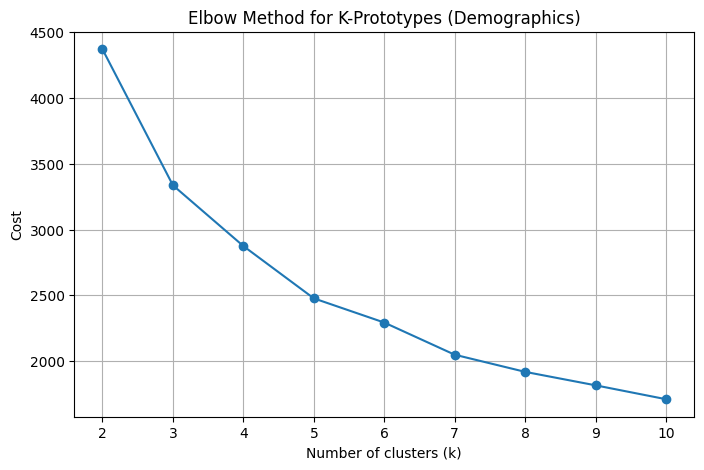

In [67]:
# Test different k values for K-Prototypes
cost = []
K_range = range(2, 11)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    kproto.fit(X_kproto, categorical=[3, 4, 5]) 
    cost.append(kproto.cost_)
    print(f"k={k}: cost={kproto.cost_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, cost, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes (Demographics)')
plt.grid(True)
plt.show()

k=2: 0.2607
k=3: 0.3689
k=4: 0.3644
k=5: 0.2305
k=6: 0.1781
k=7: 0.1392
k=8: 0.0569
k=9: 0.0397
k=10: 0.0152


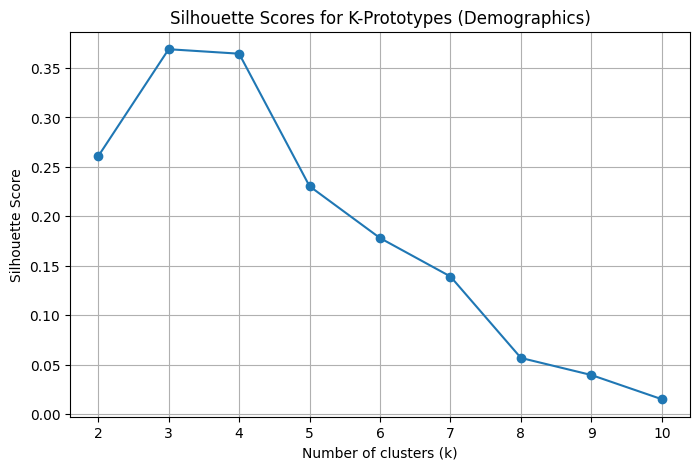

In [68]:
# Calculate silhouette scores for K-Prototypes
silhouette_scores_kproto = []

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    clusters = kproto.fit_predict(X_kproto, categorical=[3, 4, 5])
    
    # For silhouette, we use only the numerical features (scaled)
    score = silhouette_score(X_num_scaled, clusters)
    silhouette_scores_kproto.append(score)
    print(f"k={k}: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_kproto, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Prototypes (Demographics)')
plt.grid(True)
plt.show()

The elbow method shows diminishing returns after k=4, while the silhouette analysis indicates k=2 or k=4 as reasonable choices. To enable direct comparison with the K-means results, we select k=4 for K-Prototypes, which balances cluster granularity with interpretability.


Cluster sizes:
Cluster_KProto
0    4144
1    2198
2    6643
3    3587
Name: count, dtype: int64


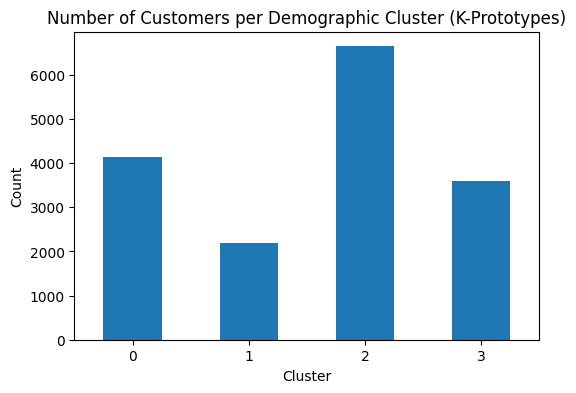

In [69]:
# K-Prototypes model with k=4
kproto_final = KPrototypes(n_clusters=4, init='Huang', random_state=42, verbose=0)
clusters_kproto = kproto_final.fit_predict(X_kproto, categorical=[3, 4, 5])

df_demo_ceiled['Cluster_KProto'] = clusters_kproto

# Cluster size distribution
cluster_counts_kproto = df_demo_ceiled['Cluster_KProto'].value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_counts_kproto)

# Visualize cluster sizes
cluster_counts_kproto.plot(kind='bar', figsize=(6,4))
plt.title('Number of Customers per Demographic Cluster (K-Prototypes)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [70]:
# Cluster profiling - numerical variables
cluster_profile_kproto = df_demo_ceiled.groupby('Cluster_KProto')[['Income', 'Latitude', 'Longitude']].mean()
print("K-Prototypes Cluster Profiles (Numerical Variables):")
print(cluster_profile_kproto)

# Cluster profiling - categorical variables
print("\n" + "="*60)
print("Gender Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_KProto'], df_demo_ceiled['Gender'], normalize='index') * 100)

print("\n" + "="*60)
print("Marital Status Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_KProto'], df_demo_ceiled['Marital Status'], normalize='index') * 100)

print("\n" + "="*60)
print("Education Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_KProto'], df_demo_ceiled['Education'], normalize='index') * 100)

K-Prototypes Cluster Profiles (Numerical Variables):
                      Income   Latitude   Longitude
Cluster_KProto                                     
0               54575.321911  50.631202 -118.254859
1                5926.546861  50.589653 -118.430844
2               54778.415776  45.045383  -75.355193
3                6236.430722  45.031902  -75.558188

Gender Distribution by Cluster:
Gender             female       male
Cluster_KProto                      
0               59.966216  40.033784
1               37.670610  62.329390
2               42.766822  57.233178
3               60.802899  39.197101

Marital Status Distribution by Cluster:
Marital Status   Divorced    Married     Single
Cluster_KProto                                 
0               15.516409  71.114865  13.368726
1               13.375796  34.986351  51.637853
2               16.001806  71.082342  12.915851
3               13.548927  33.649289  52.801784

Education Distribution by Cluster:
Education      

The K-Prototypes clustering reveals four highly distinct demographic segments:

- **Cluster 0**: High income (approximately $54,575), western region, predominantly female (60%), highly married (71%), **Bachelor-educated (92%)**
- **Cluster 1**: Very low income (approximately $5,927), western region, predominantly male (62%), mostly single (52%), **College-educated (73%)**
- **Cluster 2**: High income (approximately $54,778), eastern region, predominantly male (57%), highly married (71%), **Bachelor-educated (93%)**
- **Cluster 3**: Very low income (approximately $6,236), eastern region, predominantly female (61%), mostly single (53%), **College-educated (72%)**

In [71]:
print("Clustering Quality Metrics (K-Prototypes)")
print("=" * 50)

# Silhouette Score (using only numerical features)
sil_score_kproto = silhouette_score(X_num_scaled, clusters_kproto)
print(f"Silhouette Score: {sil_score_kproto:.4f}")

# Calinski-Harabasz Score
ch_score_kproto = calinski_harabasz_score(X_num_scaled, clusters_kproto)
print(f"Calinski-Harabasz Score: {ch_score_kproto:.4f}")

# Davies-Bouldin Score
db_score_kproto = davies_bouldin_score(X_num_scaled, clusters_kproto)
print(f"Davies-Bouldin Score: {db_score_kproto:.4f}")

Clustering Quality Metrics (K-Prototypes)
Silhouette Score: 0.3644
Calinski-Harabasz Score: 13257.7121
Davies-Bouldin Score: 0.8474


The K-Prototypes clustering quality metrics show good performance across multiple measures. The silhouette score of 0.36 indicates reasonable cluster separation and cohesion. The Calinski-Harabasz score of 13257 reflects well-defined between-cluster variance, while the Davies-Bouldin score of 0.847 suggests acceptable cluster separation with moderate overlap.

In [72]:
print("\nR² Score per Variable (Variance Explained by K-Prototypes)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster_KProto')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")

print("=" * 50)


R² Score per Variable (Variance Explained by K-Prototypes)
Income      : 0.5820
Latitude    : 0.6723
Longitude   : 0.8786


The R² scores demonstrate that K-Prototypes effectively captures variance in the demographic variables, with longitude explaining 88% of variance, latitude 67%, and income 66%. These results confirm that K-Prototypes successfully segments customers using both continuous and categorical variables, creating distinct demographic groups that combine income, geography, gender, and marital status characteristics.

## Comparison between K-Means and K-Prototypes

In [73]:
print("=" * 70)
print("COMPARISON: K-Means vs K-Prototypes")
print("=" * 70)
print(f"{'Metric':<30} {'K-Means':<20} {'K-Prototypes':<20}")
print("=" * 70)

# Silhouette scores
print(f"{'Silhouette Score':<30} {0.4975:<20.4f} {0.3644:<20.4f}")

# Calinski-Harabasz
print(f"{'Calinski-Harabasz Score':<30} {20818.1160:<20.2f} {13257.7121:<20.2f}")

# Davies-Bouldin
print(f"{'Davies-Bouldin Score':<30} {0.7268:<20.4f} {0.8474:<20.4f}")

print("=" * 70)
print("\nR² Scores Comparison")
print("=" * 70)

# R² comparison (UPDATED K-Prototypes values)
r2_kmeans = {'Income': 0.7451, 'Latitude': 0.7033, 'Longitude': 0.8889}
r2_kproto = {'Income': 0.5820, 'Latitude': 0.6723, 'Longitude': 0.8786}

for var in ['Income', 'Latitude', 'Longitude']:
    print(f"{var:<30} {r2_kmeans[var]:<20.4f} {r2_kproto[var]:<20.4f}")

print("=" * 70)

COMPARISON: K-Means vs K-Prototypes
Metric                         K-Means              K-Prototypes        
Silhouette Score               0.4975               0.3644              
Calinski-Harabasz Score        20818.12             13257.71            
Davies-Bouldin Score           0.7268               0.8474              

R² Scores Comparison
Income                         0.7451               0.5820              
Latitude                       0.7033               0.6723              
Longitude                      0.8889               0.8786              


The comparison reveals distinct trade-offs between the two approaches:

**K-Means** achieves superior performance across all technical metrics. It shows higher silhouette score (0.50 vs 0.36), indicating better cluster cohesion and separation. The Calinski-Harabasz score is substantially higher (20,818 vs 13,258), reflecting stronger between-cluster variance. K-Means also has a lower Davies-Bouldin score (0.73 vs 0.85), suggesting less cluster overlap. Most notably, K-Means explains considerably more variance in income (74.5% vs 58.2%), while maintaining similar performance on geographic variables (latitude: 70.3% vs 67.2%; longitude: 88.9% vs 87.9%).

**K-Prototypes** incorporates categorical variables (gender, marital status, and education) directly into the clustering process, creating segments with explicit demographic profiles. The resulting clusters reveal that education is a dominant driver, with Bachelor-educated customers forming high-income married segments and College-educated customers forming low-income single segments. However, the inclusion of categorical variables reduces overall clustering quality as measured by standard metrics.

K-Means is selected as the primary demographic segmentation approach due to its significantly stronger statistical performance and superior variance explanation in continuous demographic variables. The continuous variables (income and geography) prove to be the most meaningful drivers of demographic segmentation. Categorical variables such as gender, marital status, and education provide valuable profiling information and can be used to characterize and describe the K-Means clusters, but do not need to drive the cluster formation itself.

## Demographic Clustering – Hierarchical Clustering

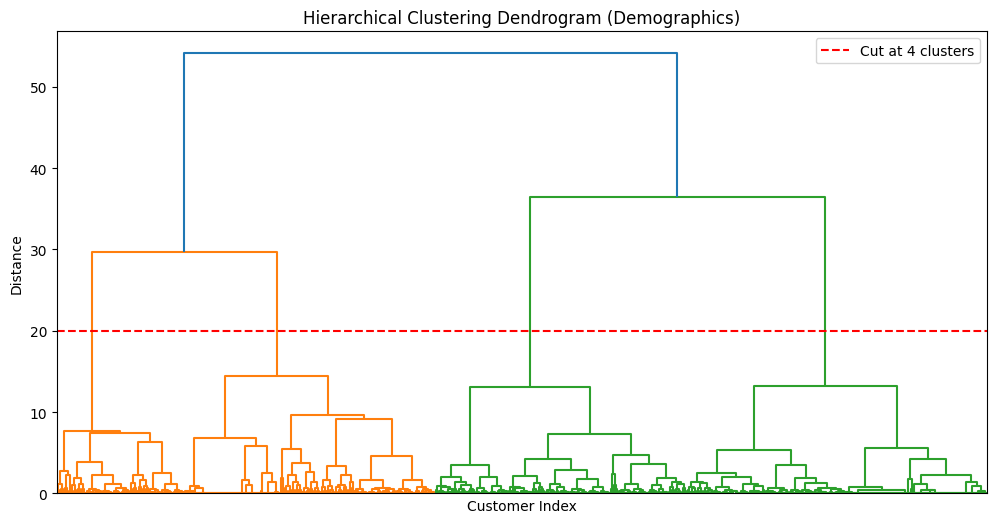

In [78]:
# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_demo_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Demographics)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=20, color='r', linestyle='--', label='Cut at 4 clusters')
plt.legend()
plt.show()

Cluster sizes (Hierarchical):
Cluster_Hierarchical
0    4465
1    5335
2    4489
3    2283
Name: count, dtype: int64


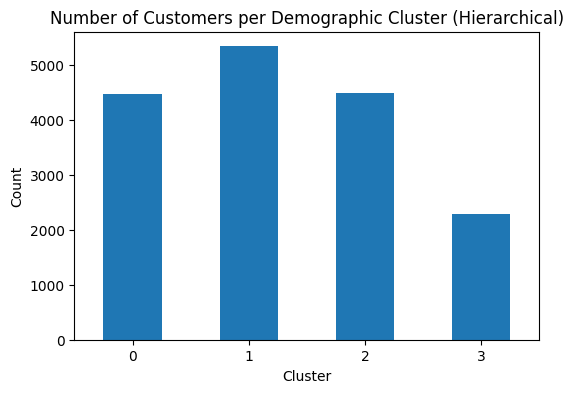

In [79]:
# Fit Hierarchical Clustering with k=4
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters_hierarchical = hierarchical.fit_predict(X_demo_scaled)

df_demo_ceiled['Cluster_Hierarchical'] = clusters_hierarchical

# Cluster size distribution
cluster_counts_hier = df_demo_ceiled['Cluster_Hierarchical'].value_counts().sort_index()
print("Cluster sizes (Hierarchical):")
print(cluster_counts_hier)

# Visualize cluster sizes
cluster_counts_hier.plot(kind='bar', figsize=(6,4))
plt.title('Number of Customers per Demographic Cluster (Hierarchical)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [80]:
# Cluster profiling
cluster_profile_hier = df_demo_ceiled.groupby('Cluster_Hierarchical')[['Income', 'Latitude', 'Longitude']].mean()
print("\nHierarchical Cluster Profiles:")
print(cluster_profile_hier)

print("\n" + "="*60)
print("Gender Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_Hierarchical'], df_demo_ceiled['Gender'], normalize='index') * 100)

print("\n" + "="*60)
print("Marital Status Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_Hierarchical'], df_demo_ceiled['Marital Status'], normalize='index') * 100)

print("\n" + "="*60)
print("Education Distribution by Cluster:")
print(pd.crosstab(df_demo_ceiled['Cluster_Hierarchical'], df_demo_ceiled['Education'], normalize='index') * 100)


Hierarchical Cluster Profiles:
                            Income   Latitude   Longitude
Cluster_Hierarchical                                     
0                     19384.910862  50.609685 -116.368957
1                     13992.865792  44.795320  -74.952266
2                     66111.226999  44.938711  -74.263420
3                     73355.634253  50.412842 -117.890791

Gender Distribution by Cluster:
Gender                   female       male
Cluster_Hierarchical                      
0                     50.884658  49.115342
1                     49.746954  50.253046
2                     49.498775  50.501225
3                     51.992992  48.007008

Marital Status Distribution by Cluster:
Marital Status         Divorced    Married     Single
Cluster_Hierarchical                                 
0                     14.826428  52.945129  32.228443
1                     14.489222  49.896907  35.613871
2                     15.883270  67.899309  16.217420
3                 

The hierarchical clustering with k=4 reveals segments organized by income, geography, and education:

- **Cluster 0**: Mid-low income (~$19,385), western region, balanced gender, 53% married, mixed education (43% Bachelor, 39% College)
- **Cluster 1**: Low income (~$13,993), eastern region, balanced gender, 50% married, mixed education (31% Bachelor, 46% College)
- **Cluster 2**: High income (~$66,111), eastern region, balanced gender, 68% married, **100% Bachelor-educated**
- **Cluster 3**: High income (~$73,356), western region, balanced gender, 69% married, **100% Bachelor-educated**

Hierarchical clustering produces a distinct pattern where high-income segments are exclusively Bachelor-degree holders, while lower-income segments show diverse education backgrounds. This confirms income and geography as primary drivers, with education strongly correlating with income level. High-income clusters also show notably higher marriage rates (~68-69%) compared to lower-income segments (~50-53%).

In [81]:
print("\nClustering Quality Metrics (Hierarchical)")
print("=" * 50)

# Silhouette Score
sil_score_hier = silhouette_score(X_demo_scaled, clusters_hierarchical)
print(f"Silhouette Score: {sil_score_hier:.4f}")

# Calinski-Harabasz Score
ch_score_hier = calinski_harabasz_score(X_demo_scaled, clusters_hierarchical)
print(f"Calinski-Harabasz Score: {ch_score_hier:.4f}")

# Davies-Bouldin Score
db_score_hier = davies_bouldin_score(X_demo_scaled, clusters_hierarchical)
print(f"Davies-Bouldin Score: {db_score_hier:.4f}")


Clustering Quality Metrics (Hierarchical)
Silhouette Score: 0.4752
Calinski-Harabasz Score: 19030.1219
Davies-Bouldin Score: 0.7379


In [82]:
# R² scores
print("\nR² Score per Variable (Hierarchical)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster_Hierarchical')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")


R² Score per Variable (Hierarchical)
Income      : 0.7218
Latitude    : 0.7139
Longitude   : 0.8716


The hierarchical clustering demonstrates strong performance with a silhouette score of 0.48, Calinski-Harabasz score of 19,030, and Davies-Bouldin score of 0.74. The R² scores show effective variance explanation across all demographic variables: 87% for longitude, 72% for income, and 71% for latitude. These metrics are comparable to K-Means, confirming that hierarchical clustering captures similar underlying demographic patterns with income and geography as the primary drivers.

In [89]:
# Export final cluster assignments for merging with other perspectives
final_clusters = pd.DataFrame(index=df_AIAI_Master.index)
final_clusters.index.name = 'Loyalty#'
final_clusters['Demographic_Cluster'] = df_demo_ceiled['Cluster']
final_clusters['Demographic_Cluster_Name'] = df_demo_ceiled['Cluster_Name']

# Reset index to make Loyalty# a column
final_clusters = final_clusters.reset_index()

# Save to CSV
final_clusters.to_csv('demographic_clusters.csv', index=False)

print("Exported demographic cluster assignments:")
print(final_clusters.head(10))
print(f"\nTotal customers: {len(final_clusters)}")
print(f"\nCluster distribution:")
print(final_clusters['Demographic_Cluster_Name'].value_counts())

Exported demographic cluster assignments:
   Loyalty#  Demographic_Cluster Demographic_Cluster_Name
0    480934                    3         High-Income East
1    549612                    2          Low-Income West
2    429460                    2          Low-Income West
3    608370                    0          Low-Income East
4    530508                    3         High-Income East
5    927943                    0          Low-Income East
6    188893                    3         High-Income East
7    852392                    3         High-Income East
8    866307                    3         High-Income East
9    932823                    1         High-Income West

Total customers: 16572

Cluster distribution:
Demographic_Cluster_Name
Low-Income East     5793
High-Income East    4282
Low-Income West     3735
High-Income West    2762
Name: count, dtype: int64
